# Notebook 2 — AbLang2 Embeddings, Oracle & PLS

Loads preprocessed data from Notebook 1.

Outputs saved to Drive:
- `cdr3_embeddings.npy`, `fw_masked_embeddings.npy`, `full_embeddings.npy`
- `oracle_hic.pkl`, `oracle_sins.pkl`
- `pls_model.pkl`, `pls_scaler.pkl`
- `flow_model_inputs.npz`

Skips any step whose output file already exists.

In [1]:
# Install required packages.
# Run this cell once. If Colab prompts to restart the runtime, do so
# and then skip back to this cell (it will already be installed).
!pip install -q ablang2        # AbLang2 antibody language model
!pip install -q torchcfm       # Conditional flow matching training loop
!pip install -q torchdiffeq    # ODE integrator for Phase 1 sampling
!pip install -q scikit-learn scipy matplotlib seaborn joblib
!pip install -q fair-esm       # ESM2 antigen embeddings
!pip install -q anarci         # IMGT CDR3 extraction for AbRank / SAbDab sequences
!pip install -q requests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 83.3 MB/s eta 0:00:00


In [2]:
import os, re, warnings, json, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import spearmanr, pearsonr, ttest_rel, ks_2samp
from scipy.spatial.distance import cdist as scipy_cdist
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold
import joblib
import requests
from difflib import get_close_matches

import esm
from anarci import anarci as anarci_number

from torchcfm.conditional_flow_matching import ConditionalFlowMatcher
from torchdiffeq import odeint

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
torch.manual_seed(42)
np.random.seed(42)

Device: cpu


In [3]:
from google.colab import drive
drive.mount('/content/drive')

# ── Directory and file paths ──────────────────────────────────────────────────
PROJECT_DIR = '/content/drive/MyDrive/2026 Spring/BMI 702/project'
EVAL_DIR    = f'{PROJECT_DIR}/eval_inputs'
DATA_PATH   = f'{PROJECT_DIR}/GDPa1_v1.2_20250814.csv'

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(EVAL_DIR,    exist_ok=True)

CACHE = lambda name: f'{PROJECT_DIR}/{name}'

# ── Dataset column names ──────────────────────────────────────────────────────
COL_VH    = 'vh_protein_sequence'
COL_VL    = 'vl_protein_sequence'
COL_HIC   = 'HIC'
COL_SINS  = 'AC-SINS_pH7.4'
COL_FOLD  = 'hierarchical_cluster_fold'
COL_AHO_H = 'heavy_aligned_aho'
COL_AHO_L = 'light_aligned_aho'
COL_NAME  = 'antibody_name'

# ── Pipeline hyperparameters ──────────────────────────────────────────────────
TEST_FOLD       = 1
N_FLOW_SAMPLES  = 50
N_ODE_STEPS     = 100
M_SEQUENCES     = 20
TEMPERATURE     = 1.0
TOP_K_SELECT    = 5
FLOW_EPOCHS     = 1000
CURRENT_SIGMA   = 0.5
PLS_COMPONENTS  = 10
AA_VOCAB        = list('ACDEFGHIKLMNPQRSTVWY')
AA_TO_IDX       = {aa: i for i, aa in enumerate(AA_VOCAB)}
ABLANG_MASK     = '*'

# ── Binding scorer hyperparameters ────────────────────────────────────────────
SCORER_HIDDEN      = 128    # shared projection dim (CDR3 and antigen)
SCORER_HEADS       = 4      # multi-head cross-attention heads
SCORER_PRETRAIN_EP = 100    # InfoNCE pretraining epochs
SCORER_FINETUNE_EP = 50     # affinity regression fine-tuning epochs
SCORER_BATCH       = 64     # contrastive pretraining batch size
ANTIGEN_MAX_LEN    = 512    # truncate antigen sequences for ESM2
GUIDANCE_LAMBDA    = 0.5    # binding gradient scale at ODE sampling time
                             # 0 = no guidance (ablation), >1 = stronger push
ESM2_DIM           = 1280   # ESM2-650M hidden dimension

Mounted at /content/drive


In [4]:
MEAN_CACHE       = f'{EVAL_DIR}/antigen_esm2_embs.npy'
RESID_CACHE      = f'{EVAL_DIR}/antigen_esm2_resid.npy'
MASK_CACHE       = f'{EVAL_DIR}/antigen_valid_mask.npy'
RESID_PAD_CACHE  = f'{EVAL_DIR}/antigen_resid_pad_mask.npy'
SAB_MEAN_CACHE   = f'{EVAL_DIR}/sabdab_ag_embs.npy'
SAB_CDR3_CACHE   = f'{EVAL_DIR}/sabdab_cdr3_embs.npy'

In [5]:
# ── Reload preprocessed data ─────────────────────────────────────────────────
df               = pd.read_csv(f'{PROJECT_DIR}/clinical_mabs_with_antigens.csv')
sabdab_pretrain  = pd.read_csv(f'{PROJECT_DIR}/abrank_stage1.csv')
sabdab_finetune  = pd.read_csv(f'{PROJECT_DIR}/abrank_stage2.csv')
sab_ag_embs      = np.load(SAB_MEAN_CACHE)

# Restore list columns serialized as strings
import ast
for col in ['h_cdr3_idx', 'h_fw_idx', 'l_cdr3_idx', 'l_fw_idx']:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Rebuild test/train split
test_mask  = df[COL_FOLD] == TEST_FOLD
train_mask = ~test_mask
test_idx   = df.index[test_mask].tolist()
train_idx  = df.index[train_mask].tolist()
print(f'Train: {len(train_idx)}  Test: {len(test_idx)}')
print(f'sabdab_pretrain: {len(sabdab_pretrain)}  sabdab_finetune: {len(sabdab_finetune)}')

Train: 196  Test: 50
sabdab_pretrain: 70999  sabdab_finetune: 4610


---
## Section 2 — AbLang2 Embedding Extraction

Three embeddings are computed per antibody from the **frozen** AbLang2 model:

| Embedding | AbLang2 mode | Used for |
|---|---|---|
| `cdr3_embs` | rescoding, mean-pool CDR3 positions | Flow model target distribution |
| `fw_embs` | rescoding with CDR3 **masked to `*`** first | Flow model conditioning |
| `full_embs` | seqcoding (mean-pool full VH+VL) | Oracle training and scoring |

**Why mask the CDR3 before computing the framework embedding?**
AbLang2 is a transformer — every position attends to every other position.
Without masking, the framework hidden states encode CDR3 information via attention.
At inference, a conditioning signal that leaks CDR3 information would let the
flow model reconstruct the original CDR3 rather than generate a novel one.
Replacing CDR3 positions with `*` before the forward pass eliminates this leak.

In [6]:
import ablang2

print('Loading AbLang2 paired model (frozen)...')
ablang = ablang2.pretrained(model_to_use='ablang2-paired',
                            random_init=False, ncpu=1, device=DEVICE)
ablang.freeze()  # never fine-tune — only 197 training points
print('AbLang2 loaded.')

Loading AbLang2 paired model (frozen)...
AbLang2 loaded.


### 2a — CDR3 embeddings

In [7]:
# Mean-pool the AbLang2 hidden states at CDR3 positions only.
# These are the TARGETS for flow model training — the model learns to
# map Gaussian noise toward this distribution of CDR3 embeddings.
CDR3_CACHE = CACHE('cdr3_embeddings.npy')

if os.path.exists(CDR3_CACHE):
    cdr3_embs = np.load(CDR3_CACHE)
    print(f'Loaded CDR3 embeddings from cache: {cdr3_embs.shape}')
else:
    print('Computing CDR3 embeddings (run once, ~10 min on T4)...')
    BATCH, cdr3_list = 8, []
    for i in range(0, len(df), BATCH):
        rows = df.iloc[i:i+BATCH]
        seqs = list(zip(rows[COL_VH], rows[COL_VL]))
        with torch.no_grad():
            reps = ablang(seqs, mode='rescoding')  # per-residue hidden states
        for j, row in enumerate(rows.itertuples()):
            hidden = np.array(reps[j])
            vh_len = len(row.vh_protein_sequence)
            h_hid  = hidden[:vh_len]  # VH portion only
            valid  = [k for k in row.h_cdr3_idx if k < len(h_hid)]
            cdr3_list.append(h_hid[valid].mean(0) if valid else np.zeros(480))
        if i % 40 == 0: print(f'  {min(i+BATCH, len(df))}/{len(df)}')
    cdr3_embs = np.vstack(cdr3_list)
    np.save(CDR3_CACHE, cdr3_embs)
    print(f'Saved: {cdr3_embs.shape}')

CDR3_DIM = cdr3_embs.shape[1]  # 480

Loaded CDR3 embeddings from cache: (246, 480)


### 2b — Masked framework embeddings

In [8]:
FW_CACHE = CACHE('fw_masked_embeddings.npy')

def mask_cdr3(vh_seq, cdr3_idx):
    """Replace CDR3 positions with AbLang2 mask token before forward pass."""
    chars = list(vh_seq)
    for i in cdr3_idx:
        if i < len(chars): chars[i] = ABLANG_MASK
    return ''.join(chars)

if os.path.exists(FW_CACHE):
    fw_embs = np.load(FW_CACHE)
    print(f'Loaded FW embeddings from cache: {fw_embs.shape}')
else:
    print('Computing masked-framework embeddings...')
    BATCH, fw_list = 8, []
    for i in range(0, len(df), BATCH):
        rows = df.iloc[i:i+BATCH]
        # Mask CDR3 residues in each VH before the forward pass
        masked_seqs = [(mask_cdr3(r.vh_protein_sequence, r.h_cdr3_idx),
                        r.vl_protein_sequence)
                       for r in rows.itertuples()]
        with torch.no_grad():
            reps = ablang(masked_seqs, mode='rescoding')
        for j, row in enumerate(rows.itertuples()):
            hidden = np.array(reps[j])
            vh_len = len(row.vh_protein_sequence)
            vl_len = len(row.vl_protein_sequence)
            n_ex   = hidden.shape[0] - vh_len - vl_len
            h_hid  = hidden[:vh_len]
            l_hid  = hidden[vh_len + n_ex:]
            # Framework = non-CDR3 VH positions + all VL positions
            fw_h = h_hid[row.h_fw_idx].mean(0) if row.h_fw_idx else np.zeros(480)
            vl_v = list(range(min(vl_len, l_hid.shape[0])))
            fw_l = l_hid[vl_v].mean(0) if vl_v else np.zeros(480)
            fw_list.append((fw_h + fw_l) / 2.0)
        if i % 40 == 0: print(f'  {min(i+BATCH, len(df))}/{len(df)}')
    fw_embs = np.vstack(fw_list)
    np.save(FW_CACHE, fw_embs)
    print(f'Saved: {fw_embs.shape}')

FW_DIM = fw_embs.shape[1]

Loaded FW embeddings from cache: (246, 480)


### 2c — Full-sequence embeddings (oracle input)

In [9]:
# seqcoding returns one 480d vector per antibody (mean-pool over full VH+VL).
# HIC and AC-SINS are whole-molecule properties — CDR3-only embeddings have
# weaker predictive power. The oracle needs the full sequence representation.
FULL_CACHE = CACHE('full_embeddings.npy')

if os.path.exists(FULL_CACHE):
    full_embs = np.load(FULL_CACHE)
    print(f'Loaded full embeddings from cache: {full_embs.shape}')
else:
    print('Computing full-sequence embeddings...')
    BATCH, full_list = 16, []
    for i in range(0, len(df), BATCH):
        rows = df.iloc[i:i+BATCH]
        seqs = list(zip(rows[COL_VH], rows[COL_VL]))
        with torch.no_grad():
            emb = ablang(seqs, mode='seqcoding')
        full_list.append(emb if isinstance(emb, np.ndarray)
                          else emb.cpu().numpy())
        if i % 64 == 0: print(f'  {min(i+BATCH, len(df))}/{len(df)}')
    full_embs = np.vstack(full_list)
    np.save(FULL_CACHE, full_embs)
    print(f'Saved: {full_embs.shape}')

FULL_DIM = full_embs.shape[1]
print(f'Dims — CDR3: {CDR3_DIM}, FW: {FW_DIM}, Full: {FULL_DIM}')

Loaded full embeddings from cache: (246, 480)
Dims — CDR3: 480, FW: 480, Full: 480


### 2d — Embedding space analysis

Three diagnostics that should be run before training:
1. **Intrinsic dimensionality**: how many PCA components explain 90% of CDR3 variance?
2. **Developability gradient**: do PC1–PC2 show HIC/AC-SINS structure? (usually no — developability directions are in higher PCs)
3. **Test set position**: do fold-1 antibodies fall inside the training distribution?

In [12]:
# Impute the ~3 missing HIC and AC-SINS values using the TRAINING-SET median.
# Computing the median on the full dataset would leak fold-1 statistics
# into the normalization. We compute on folds 2-5 only and apply everywhere.
def impute_train_median(df, col, train_idx):
    vals   = df[col].copy().astype(float)
    median = float(np.nanmedian(vals.values[train_idx]))
    return vals.fillna(median).values, median

y_hic,  hic_med  = impute_train_median(df, COL_HIC,  train_idx)
y_sins, sins_med = impute_train_median(df, COL_SINS, train_idx)


y_hic_train,  y_hic_test  = y_hic[train_idx],  y_hic[test_idx]
y_sins_train, y_sins_test = y_sins[train_idx], y_sins[test_idx]

CDR3 embedding intrinsic dimensionality:
  9 PCs explain 50% variance
  51 PCs explain 90% variance
  (Full space = 480d — effective dim is much lower)


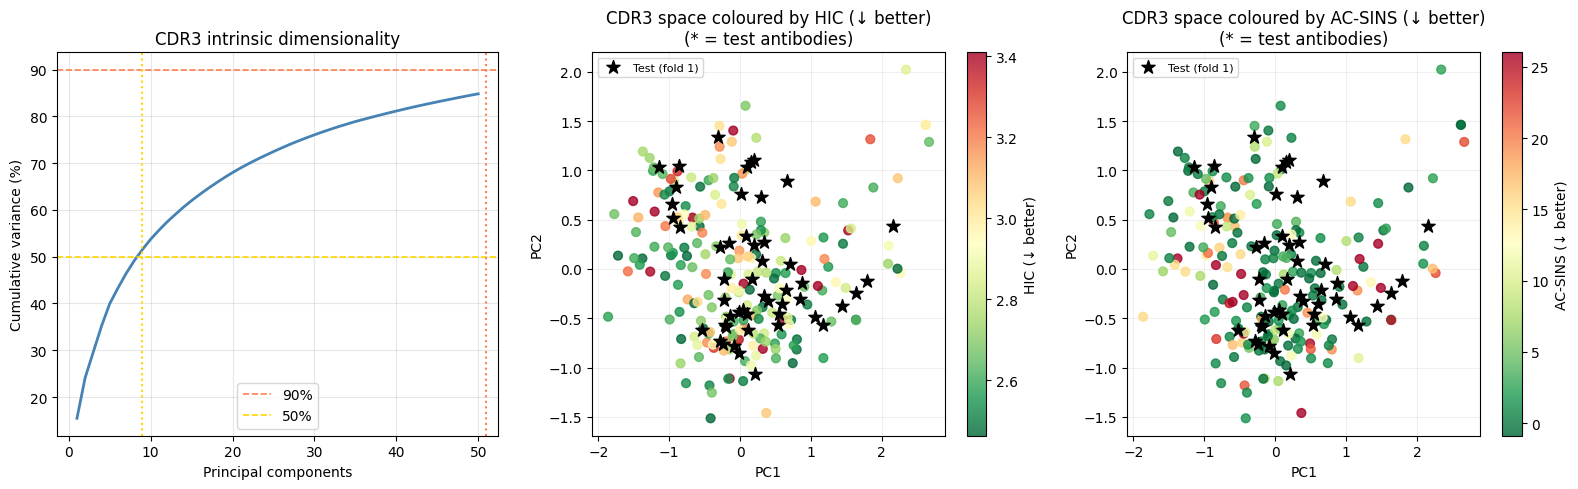

Within-train NN dist (95th pctile): 1.81
Test NN dist: mean=1.29  median=1.27  max=1.72
✓ All test antibodies within training distribution range


In [13]:
# Fit PCA on training CDR3 embeddings ONLY.
# Using all 246 would leak test-set variance into the PCA directions.
pca = PCA(n_components=50, random_state=42)
pca.fit(cdr3_embs[train_idx])

cumvar = np.cumsum(pca.explained_variance_ratio_)
n_90   = int(np.searchsorted(cumvar, 0.90)) + 1
n_50   = int(np.searchsorted(cumvar, 0.50)) + 1
print(f'CDR3 embedding intrinsic dimensionality:')
print(f'  {n_50} PCs explain 50% variance')
print(f'  {n_90} PCs explain 90% variance')
print(f'  (Full space = {CDR3_DIM}d — effective dim is much lower)')

pc_train = pca.transform(cdr3_embs[train_idx])
pc_test  = pca.transform(cdr3_embs[test_idx])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: cumulative explained variance
ax = axes[0]
ax.plot(range(1, 51), cumvar * 100, lw=2, color='steelblue')
ax.axhline(90, color='coral', ls='--', lw=1.2, label='90%')
ax.axhline(50, color='gold',  ls='--', lw=1.2, label='50%')
ax.axvline(n_90, color='coral', ls=':')
ax.axvline(n_50, color='gold',  ls=':')
ax.set(xlabel='Principal components', ylabel='Cumulative variance (%)',
       title='CDR3 intrinsic dimensionality')
ax.legend(); ax.grid(True, alpha=0.3)

# Plots 2-3: PC1 vs PC2 coloured by HIC and AC-SINS
for ax, (y_tr, label, cmap) in zip(axes[1:], [
        (y_hic_train,  'HIC (↓ better)',      'RdYlGn_r'),
        (y_sins_train, 'AC-SINS (↓ better)',  'RdYlGn_r')]):
    sc = ax.scatter(pc_train[:,0], pc_train[:,1], c=y_tr,
                    cmap=cmap, s=40, alpha=0.8, zorder=2,
                    vmin=np.percentile(y_tr,5), vmax=np.percentile(y_tr,95))
    ax.scatter(pc_test[:,0], pc_test[:,1], c='black',
               marker='*', s=100, label='Test (fold 1)', zorder=3)
    plt.colorbar(sc, ax=ax, label=label)
    ax.set(xlabel='PC1', ylabel='PC2',
           title=f'CDR3 space coloured by {label}\n(* = test antibodies)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(CACHE('embedding_space_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Test-set OOD check ────────────────────────────────────────────────────────
# Compute within-training nearest-neighbour distances (excluding self-pairs)
# to define a 'normal' inter-point gap. Flag test antibodies that are farther
# from any training point than the 95th percentile of that gap distribution.
train_pc20 = pc_train[:, :20]
test_pc20  = pc_test[:,  :20]

train_pw = scipy_cdist(train_pc20, train_pc20)
np.fill_diagonal(train_pw, np.inf)  # exclude self-distances
train_nn  = train_pw.min(axis=1)
threshold = np.percentile(train_nn, 95)

nn_dists = scipy_cdist(test_pc20, train_pc20).min(axis=1)
outliers = np.where(nn_dists > threshold)[0]

print(f'Within-train NN dist (95th pctile): {threshold:.2f}')
print(f'Test NN dist: mean={nn_dists.mean():.2f}  '
      f'median={np.median(nn_dists):.2f}  max={nn_dists.max():.2f}')
if len(outliers):
    print(f'OOD test antibodies: {len(outliers)}')
    for i in outliers:
        print(f'  {df.iloc[test_idx[i]][COL_NAME]}')
else:
    print('✓ All test antibodies within training distribution range')

---
## Section 3 — Oracle Training

Ridge regression predicts HIC and AC-SINS from AbLang2 full-sequence embeddings.
Trained on folds 2–5 only. Fold-1 labels are **never** used during training.

Ridge is appropriate here because:
- N=197 training points is small for a deep model
- The oracle is used for candidate **ranking** not absolute prediction
- It matches the Ginkgo Bioworks baseline (Zhao et al. 2025) for comparison

In [14]:
# Scalers must be fit on training data only.
# Fitting on all 246 antibodies would leak test-set mean/std into normalization.
full_scaler = StandardScaler()
X_full_tr   = full_scaler.fit_transform(full_embs[train_idx])
X_full_te   = full_scaler.transform(full_embs[test_idx])

# Train separate Ridge regressors for HIC and AC-SINS
oracle_hic  = Ridge(alpha=0.1).fit(X_full_tr, y_hic_train)
oracle_sins = Ridge(alpha=0.1).fit(X_full_tr, y_sins_train)

# Evaluate on held-out fold 1
pred_hic  = oracle_hic.predict(X_full_te)
pred_sins = oracle_sins.predict(X_full_te)

rho_h, _ = spearmanr(y_hic_test,  pred_hic)
rho_s, _ = spearmanr(y_sins_test, pred_sins)
r_h,   _ = pearsonr( y_hic_test,  pred_hic)
r_s,   _ = pearsonr( y_sins_test, pred_sins)

print('Oracle performance on held-out fold 1:')
print(f'  HIC   — Spearman ρ: {rho_h:.3f}   Pearson R: {r_h:.3f}')
print(f'  SINS  — Spearman ρ: {rho_s:.3f}   Pearson R: {r_s:.3f}')
print('Reference (Ginkgo 2025): HIC ρ=0.42±0.09  SINS ρ=0.49±0.09')

# 4-fold cross-validation within training set to verify no overfitting
kf = KFold(n_splits=4, shuffle=True, random_state=42)
cv_h, cv_s = [], []
for tr, va in kf.split(X_full_tr):
    sc  = StandardScaler().fit(X_full_tr[tr])
    xtr = sc.transform(X_full_tr[tr])
    xva = sc.transform(X_full_tr[va])
    cv_h.append(spearmanr(y_hic_train[va],
                          Ridge(alpha=0.1).fit(xtr, y_hic_train[tr]).predict(xva))[0])
    cv_s.append(spearmanr(y_sins_train[va],
                          Ridge(alpha=0.1).fit(xtr, y_sins_train[tr]).predict(xva))[0])
print(f'\n4-fold CV: HIC ρ={np.mean(cv_h):.3f}±{np.std(cv_h):.3f}  '
      f'SINS ρ={np.mean(cv_s):.3f}±{np.std(cv_s):.3f}')

Oracle performance on held-out fold 1:
  HIC   — Spearman ρ: 0.321   Pearson R: 0.311
  SINS  — Spearman ρ: 0.445   Pearson R: 0.333
Reference (Ginkgo 2025): HIC ρ=0.42±0.09  SINS ρ=0.49±0.09

4-fold CV: HIC ρ=0.348±0.016  SINS ρ=0.549±0.097


---
## Section 4 — PLS Dimensionality Reduction for Flow Model

**Why reduce dimensions before training the flow model?**

The CDR3 embedding space is 480d but only ~50 effective dimensions carry variance
(from Section 2d). Worse, most of those 50 dimensions have nothing to do with
HIC or AC-SINS — the flow model would need to navigate 480d space where most
directions are noise, using only 197 training points.

PLS (Partial Least Squares) finds the directions in CDR3 embedding space that
maximally correlate with HIC and AC-SINS simultaneously. Unlike PCA which
maximises variance, PLS maximises covariance with the targets — every dimension
it extracts is directly developability-relevant.

With 10 PLS components, the flow model works in 10d where all dimensions encode
developability signal, with ~20 training points per dimension instead of 0.4.

In [15]:
# Fit PLS on training CDR3 embeddings with HIC and AC-SINS as joint targets.
# n_components=10: enough to capture the main developability signal without
# overfitting on 197 training points.
pls = PLSRegression(n_components=PLS_COMPONENTS)
pls.fit(
    cdr3_embs[train_idx],
    np.stack([y_hic_train, y_sins_train], axis=1))  # shape (197, 2)

# Project all CDR3 embeddings to PLS space
X_cdr3_tr_pls = pls.transform(cdr3_embs[train_idx])  # (197, 10)
X_cdr3_te_pls = pls.transform(cdr3_embs[test_idx])   # (49, 10)

print(f'PLS projection: 480d → {PLS_COMPONENTS}d')
print(f'Training set: {X_cdr3_tr_pls.shape}')

# Verify PLS components correlate with developability scores
print('\nSpearman ρ between PLS components and oracle targets (training set):')
for k in range(min(5, PLS_COMPONENTS)):
    rho_h, _ = spearmanr(X_cdr3_tr_pls[:, k], y_hic_train)
    rho_s, _ = spearmanr(X_cdr3_tr_pls[:, k], y_sins_train)
    print(f'  PLS{k+1}: HIC ρ={rho_h:+.3f}  SINS ρ={rho_s:+.3f}')

# Scale PLS embeddings (fit scaler on training only)
pls_scaler    = StandardScaler()
X_pls_tr_sc   = pls_scaler.fit_transform(X_cdr3_tr_pls)
X_pls_te_sc   = pls_scaler.transform(X_cdr3_te_pls)

# Scale framework embeddings (used as conditioning signal)
fw_scaler     = StandardScaler()
cdr3_scaler   = StandardScaler()
X_fw_tr       = fw_scaler.fit_transform(fw_embs[train_idx])
X_fw_te       = fw_scaler.transform(fw_embs[test_idx])
X_cdr3_tr     = cdr3_scaler.fit_transform(cdr3_embs[train_idx])
X_cdr3_te     = cdr3_scaler.transform(cdr3_embs[test_idx])

# Scale developability targets for conditioning
dev_scaler     = StandardScaler()
dev_train_sc   = dev_scaler.fit_transform(
    np.stack([y_hic_train, y_sins_train], axis=1))  # (197, 2)

PLS_DIM = PLS_COMPONENTS
print(f'\nScalers fitted on folds 2-5 only.')

# ── PLS inverse transform (differentiable, for ODE guidance) ──────────────────
PLS_LOADINGS_T  = torch.tensor(pls.x_loadings_.T,
                                dtype=torch.float32).to(DEVICE)
PLS_MEAN        = torch.tensor(pls._x_mean,
                                dtype=torch.float32).to(DEVICE)
PLS_SCALER_STD  = torch.tensor(pls_scaler.scale_,
                                dtype=torch.float32).to(DEVICE)
PLS_SCALER_MEAN = torch.tensor(pls_scaler.mean_,
                                dtype=torch.float32).to(DEVICE)

def inverse_pls_torch(x_pls_scaled):
    x_raw = x_pls_scaled * PLS_SCALER_STD + PLS_SCALER_MEAN
    x_480 = x_raw @ PLS_LOADINGS_T + PLS_MEAN
    return x_480

print('PLS inverse transform registered.')


PLS projection: 480d → 10d
Training set: (196, 10)

Spearman ρ between PLS components and oracle targets (training set):
  PLS1: HIC ρ=+0.291  SINS ρ=-0.570
  PLS2: HIC ρ=-0.374  SINS ρ=-0.326
  PLS3: HIC ρ=-0.388  SINS ρ=-0.100
  PLS4: HIC ρ=-0.256  SINS ρ=-0.186
  PLS5: HIC ρ=+0.214  SINS ρ=+0.115

Scalers fitted on folds 2-5 only.
PLS inverse transform registered.


In [16]:
# ── Save notebook 2 outputs ──────────────────────────────────────────────────
joblib.dump(oracle_hic,   CACHE('oracle_hic.pkl'))
joblib.dump(oracle_sins,  CACHE('oracle_sins.pkl'))
joblib.dump(full_scaler,  CACHE('full_scaler.pkl'))
joblib.dump(pls,          CACHE('pls_model.pkl'))
joblib.dump(pls_scaler,   CACHE('pls_scaler.pkl'))
joblib.dump(dev_scaler,   CACHE('dev_scaler.pkl'))
np.savez(CACHE('flow_model_inputs.npz'),
         X_pls_tr_sc=X_pls_tr_sc, X_pls_te_sc=X_pls_te_sc,
         X_fw_tr=X_fw_tr, X_fw_te=X_fw_te,
         y_hic_train=y_hic_train, y_sins_train=y_sins_train,
         test_idx=np.array(test_idx), train_idx=np.array(train_idx))
print('Saved all Notebook 2 outputs.')

Saved all Notebook 2 outputs.


## Embeddings + Oracle + PLS Complete

Proceed to `notebook3_model_training.ipynb`.